In [1]:
import os
from dotenv import load_dotenv
from pathlib import Path

import datetime
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# environment variables
env_path = Path("/home/jovyan/.env")
load_dotenv(env_path)

# mounted data directory in container
data_path = Path("/home/jovyan/data/data-main")

print("cwd:", Path.cwd())
print("data_path:", data_path)
print("exists:", data_path.exists())

cwd: /home/jovyan
data_path: /home/jovyan/data/data-main
exists: True


### [2]株価データ取得

In [3]:
# Yahoo Finance から株価を取得
tickers = ['0700.HK', '0175.HK']  # Tencent, Geely
start = datetime.date(2019, 1, 1)
end = datetime.date(2025, 3, 31)

def convert_prices_to_returns(price_df, method='simple'):
    if method == 'simple':
        returns = price_df.pct_change()
    elif method == 'log':
        returns = np.log(price_df / price_df.shift(1))
    else:
        raise ValueError("method must be 'simple' or 'log'")
    return returns.dropna()

yahoo_price_df = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=True,
    progress=False,
    group_by='column'
 )['Close']

if isinstance(yahoo_price_df, pd.Series):
    yahoo_price_df = yahoo_price_df.to_frame()

yahoo_price_df = yahoo_price_df.rename(columns={'0700.HK': '700.HK', '0175.HK': '175.HK'})
yahoo_simple_returns = convert_prices_to_returns(yahoo_price_df, method='simple')
yahoo_log_returns = convert_prices_to_returns(yahoo_price_df, method='log')
yahoo_simple_returns.head()

Ticker,175.HK,700.HK
Date,,
2019-01-03,-0.081664,-0.005218
2019-01-04,-0.003356,0.018361
2019-01-07,-0.030303,0.022537
2019-01-08,-0.112847,-0.006297
2019-01-09,0.084149,0.038023


In [4]:
# CSVファイルからリターンを読み込み
# finance/data/data-main/2_1_efrontier_data.csv
csv_df = pd.read_csv(data_path / "2_1_efrontier_data.csv", index_col=0, parse_dates=True).sort_index()
df = csv_df.copy()
csv_df.head()

,700.HK,175.HK
Date,,
2019-01-03,-0.005197,-0.081662
2019-01-04,0.018347,-0.003475
2019-01-07,0.022530,-0.030188
2019-01-08,-0.006287,-0.112830
2019-01-09,0.037985,0.084093


### [3]ポートフォリオ収益率の平均・分散・共分散を算出

In [5]:
Rp = df.mean() * 250
VAR_Rp = df.var() * 250
Cov_Rp = df['700.HK'].cov(df['175.HK']) * 250

### [4]資産比率別平均リターンの算出

In [6]:
# 0%〜100%を1%刻みで101点
weights = np.arange(0.0, 1.01, 0.01)
E_Rp = weights * Rp["700.HK"] + (1 - weights) * Rp["175.HK"]

### [5]資産比率別標準偏差の算出

In [7]:
VAR_Rp2 = (
    weights**2 * VAR_Rp["700.HK"]
    + (1 - weights)**2 * VAR_Rp["175.HK"]
    + 2 * weights * (1 - weights) * Cov_Rp
)
Sigma_Rp = np.sqrt(VAR_Rp2)

In [8]:
Sigma_Rp

array([0.50968046, 0.50609986, 0.5025398 , 0.49900071, 0.49548305,
       0.49198727, 0.48851385, 0.48506326, 0.481636  , 0.47823257,
       0.47485348, 0.47149925, 0.46817042, 0.46486754, 0.46159115,
       0.45834183, 0.45512016, 0.45192674, 0.44876215, 0.44562702,
       0.44252198, 0.43944765, 0.4364047 , 0.43339377, 0.43041555,
       0.42747072, 0.42455997, 0.421684  , 0.41884354, 0.41603931,
       0.41327205, 0.4105425 , 0.40785143, 0.4051996 , 0.40258778,
       0.40001676, 0.39748734, 0.3950003 , 0.39255646, 0.39015662,
       0.38780161, 0.38549225, 0.38322935, 0.38101376, 0.37884629,
       0.37672779, 0.37465907, 0.37264097, 0.37067432, 0.36875994,
       0.36689864, 0.36509124, 0.36333855, 0.36164136, 0.36000045,
       0.35841659, 0.35689056, 0.35542308, 0.35401489, 0.35266671,
       0.35137921, 0.35015307, 0.34898894, 0.34788744, 0.34684917,
       0.34587469, 0.34496454, 0.34411925, 0.34333927, 0.34262507,
       0.34197705, 0.34139559, 0.34088104, 0.34043368, 0.34005

In [9]:
VAR_Rp2

array([0.25977417, 0.25613707, 0.25254625, 0.24900171, 0.24550345,
       0.24205147, 0.23864578, 0.23528637, 0.23197324, 0.22870639,
       0.22548583, 0.22231154, 0.21918354, 0.21610183, 0.21306639,
       0.21007724, 0.20713436, 0.20423777, 0.20138747, 0.19858344,
       0.1958257 , 0.19311424, 0.19044906, 0.18783016, 0.18525755,
       0.18273122, 0.18025117, 0.1778174 , 0.17542991, 0.17308871,
       0.17079379, 0.16854515, 0.16634279, 0.16418672, 0.16207692,
       0.16001341, 0.15799618, 0.15602524, 0.15410057, 0.15222219,
       0.15039009, 0.14860427, 0.14686474, 0.14517148, 0.14352451,
       0.14192382, 0.14036942, 0.13886129, 0.13739945, 0.13598389,
       0.13461461, 0.13329162, 0.1320149 , 0.13078447, 0.12960032,
       0.12846245, 0.12737087, 0.12632557, 0.12532655, 0.12437381,
       0.12346735, 0.12260718, 0.12179328, 0.12102567, 0.12030435,
       0.1196293 , 0.11900054, 0.11841806, 0.11788186, 0.11739194,
       0.1169483 , 0.11655095, 0.11619988, 0.11589509, 0.11563

### [6]可視化

Text(0, 0.5, 'Expected Return')

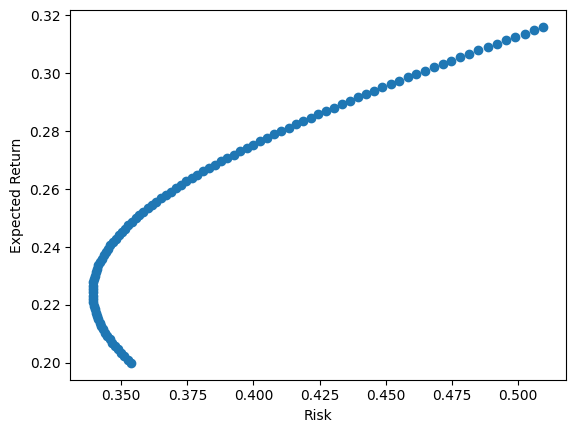

In [10]:
plt.scatter(Sigma_Rp, E_Rp)
plt.xlabel('Risk')
plt.ylabel('Expected Return')

### [7]シャープレシオの算出

In [11]:
rf = 0.03157
columun = ['Ratio']
mean_variance = pd.DataFrame(data=weights, columns=columun)
# pandasデータ配列へ変換
mean_variance['Risk'] = pd.DataFrame(Sigma_Rp)
mean_variance['Expected_Returns'] = pd.DataFrame(E_Rp)
mean_variance['Sharpe_Ratio'] = ((E_Rp - rf) / Sigma_Rp)
s_ratio = (E_Rp - rf) / Sigma_Rp
max_sr = np.amax(s_ratio)

### [8]最適資産比率の導出

In [12]:
optimal = pd.DataFrame(mean_variance.loc[mean_variance['Sharpe_Ratio'].idxmax()])
opt_risk = optimal.iloc[1, 0]
opt_return = optimal.iloc[2, 0]
optimal

,49
Ratio,0.490000
Risk,0.368760
Expected_Returns,0.259144
Sharpe_Ratio,0.617134


### [9]資産市場線


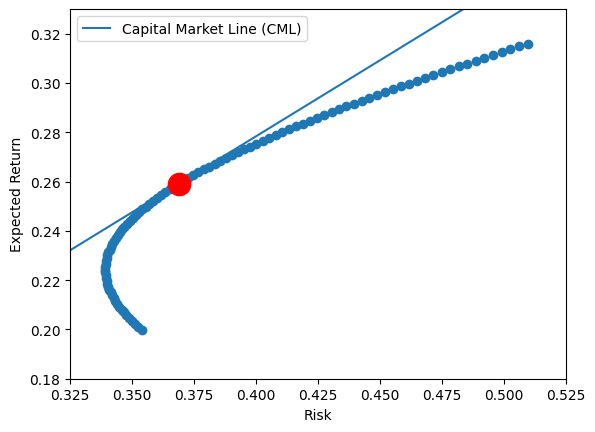

In [13]:
def CML(rf, sharp_R, label):
    Risk = [x / 100 for x in range(100)]
    ExpectedReturn = [rf + max_sr * x for x in Risk]
    # 縦軸 Ep を算出
    plt.plot(Risk, ExpectedReturn, label=label)
    plt.xlabel('Risk')
    plt.xlim(0.325, 0.525)
    plt.ylabel('Expected Return')
    plt.ylim(0.18, 0.33)
    plt.plot(opt_risk, sharp_R, "ro", linestyle="--", markersize=16)
    
CML(rf, opt_return, "Capital Market Line (CML)")
plt.scatter(Sigma_Rp, E_Rp)
plt.legend()
plt.show()

In [14]:
common_dates = csv_df.index.intersection(yahoo_simple_returns.index)
comparison_rows = []

for ticker in ['700.HK', '175.HK']:
    csv_series = csv_df.loc[common_dates, ticker]
    simple_series = yahoo_simple_returns.loc[common_dates, ticker]
    log_series = yahoo_log_returns.loc[common_dates, ticker]
    simple_diff = (csv_series - simple_series).dropna()
    log_diff = (csv_series - log_series).dropna()
    comparison_rows.append({
        'Ticker': ticker,
        'sample_size': len(simple_diff),
        'simple_mae': simple_diff.abs().mean(),
        'log_mae': log_diff.abs().mean(),
        'simple_rmse': np.sqrt((simple_diff ** 2).mean()),
        'log_rmse': np.sqrt((log_diff ** 2).mean()),
        'simple_corr': csv_series.corr(simple_series),
        'log_corr': csv_series.corr(log_series),
        'inferred_return_type': 'simple' if simple_diff.abs().mean() < log_diff.abs().mean() else 'log'
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Ticker')
comparison_df

,sample_size,simple_mae,log_mae,simple_rmse,log_rmse,simple_corr,log_corr,inferred_return_type
Ticker,,,,,,,,
700.HK,740,0.000025,0.000267,0.000229,0.000628,0.999947,0.999668,simple
175.HK,740,0.000040,0.000536,0.000238,0.001326,0.999973,0.999298,simple


In [15]:
all_simple = (comparison_df['inferred_return_type'] == 'simple').all()
print('CSV inferred return type:', 'simple' if all_simple else 'mixed/log')
print()
print(comparison_df[['sample_size', 'simple_mae', 'log_mae', 'simple_corr', 'log_corr', 'inferred_return_type']])
assert all_simple, 'CSV does not match simple returns better for all tickers'

CSV inferred return type: simple

        sample_size  simple_mae   log_mae  simple_corr  log_corr  \
Ticker                                                             
700.HK          740    0.000025  0.000267     0.999947  0.999668   
175.HK          740    0.000040  0.000536     0.999973  0.999298   

       inferred_return_type  
Ticker                       
700.HK               simple  
175.HK               simple  
